In [1]:
import os
import requests
import pandas as pd
from dotenv import load_dotenv

# Carrega as variáveis do seu arquivo .env
load_dotenv()
API_KEY = os.getenv("NASA_API_KEY")

def fetch_apod_corpus(count: int = 30) -> pd.DataFrame:
    """
    Extrai imagens e explicações aleatórias da API APOD da NASA.
    O parâmetro 'count' define quantos textos queremos baixar.
    """
    url = f"https://api.nasa.gov/planetary/apod?api_key={API_KEY}&count={count}"
    
    print(f"Coletando {count} textos da NASA para o nosso Corpus...")
    response = requests.get(url)
    
    if response.status_code == 200:
        dados = response.json()
        # Transformamos em um DataFrame, pegando as colunas que importam
        df = pd.DataFrame(dados)[['date', 'title', 'explanation', 'url']]
        return df
    else:
        print(f"Erro na extração: {response.status_code}")
        return pd.DataFrame()

# Executando a extração
df_apod = fetch_apod_corpus(50) # Vamos pegar 50 textos para começar
display(df_apod.head())

Coletando 50 textos da NASA para o nosso Corpus...


,date,title,explanation,url
0,2006-02-06,The N44 Superbubble,What created this gigantic hole? The vast emi...,https://apod.nasa.gov/apod/image/0602/n44_gemi...
1,1998-09-24,The North Pole Of Mars,The North Pole of Mars is capped by layers lik...,https://apod.nasa.gov/apod/image/9809/marsnort...
2,2016-09-20,The Helix Nebula in Infrared,What makes this cosmic eye look so red? Dust....,https://apod.nasa.gov/apod/image/1609/Helix_Sp...
3,1998-09-02,Saturn from Earth,Saturn is the second largest planet in our Sol...,https://apod.nasa.gov/apod/image/9809/saturn_n...
4,2010-04-13,Unusual Spiral Galaxy M66 from Hubble,Why isn't spiral galaxy M66 symmetric? Usuall...,https://apod.nasa.gov/apod/image/1004/m66_hst.jpg


In [2]:
import spacy
import pandas as pd

# Carregando o modelo linguístico do spaCy em inglês
# 'en_core_web_sm' significa: English, Core (Vocabulário Geral), Web (Treinado na Internet), Small (Pequeno/Rápido)
print("Carregando o modelo do spaCy...")
nlp = spacy.load("en_core_web_sm")

def clean_and_lemmatize(text: str) -> str:
    """
    Passa o texto bruto pelo pipeline do spaCy:
    - Transforma em minúsculas
    - Tokeniza (fatia em palavras)
    - Remove pontuação, números e stopwords
    - Extrai o 'Lemma' (raiz da palavra)
    """
    # Garantir que não vai processar valores nulos
    if not isinstance(text, str):
        return ""
        
    # O objeto 'doc' processa o texto inteiro aplicando as regras do inglês
    doc = nlp(text.lower())
    
    clean_tokens = []
    for token in doc:
        # Filtro: Ignorar stopwords, pontuação, números e espaços em branco
        if not token.is_stop and not token.is_punct and not token.like_num and not token.is_space:
            # Pegamos o lemma (a raiz) da palavra
            clean_tokens.append(token.lemma_)
            
    # Junta os tokens limpos de volta em uma string (separada por espaços)
    return " ".join(clean_tokens)

# Aplicando a função na coluna 'explanation' do DataFrame da NASA
print("Iniciando o pré-processamento do Corpus da NASA...")
df_apod['cleaned_text'] = df_apod['explanation'].apply(clean_and_lemmatize)

# Comparando o Antes e o Depois do primeiro texto
print("\n--- ANTES (Texto Bruto) ---")
print(df_apod['explanation'].iloc[0][:200] + "...") # Mostrando só os primeiros 200 caracteres

print("\n--- DEPOIS (Texto Limpo e Lematizado) ---")
print(df_apod['cleaned_text'].iloc[0][:200] + "...")

Carregando o modelo do spaCy...
Iniciando o pré-processamento do Corpus da NASA...

--- ANTES (Texto Bruto) ---
What created this gigantic hole?  The vast emission nebula N44 in our neighboring galaxy the Large Magellanic Cloud has a large, 250 light-year hole and astronomers are trying to figure out why.  One ...

--- DEPOIS (Texto Limpo e Lematizado) ---
create gigantic hole vast emission nebula n44 neighboring galaxy large magellanic cloud large light year hole astronomer try figure possibility particle wind expel massive star bubble interior push gl...


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
import pandas as pd


# PASSO 1: VETORIZAÇÃO (Transformando o texto limpo em uma matriz matemática)

print("Convertendo textos para matriz TF-IDF...")

# ignorar palavras que aparecem em mais de 90% dos textos (max_df)
# ou em menos de 2 textos (min_df), pois são irrelevantes para achar padrões gerais.
vectorizer = TfidfVectorizer(max_df=0.90, min_df=2)

# Transforma a coluna 'cleaned_text' em uma matriz (textos x palavras)
tfidf_matrix = vectorizer.fit_transform(df_apod['cleaned_text'])

# Para matar a curiosidade: ver o tamanho da matriz
print(f"Dimensões da Matriz: {tfidf_matrix.shape[0]} textos x {tfidf_matrix.shape[1]} palavras únicas com peso.")


# PASSO 2: MODELAGEM DE TÓPICOS (A Inteligência Artificial trabalhando)

print("\nAplicando a IA para descobrir os Tópicos Ocultos...")

# Aqui pede para o algoritmo descobrir 5 tópicos (assuntos) diferentes no corpus
NUM_TOPICOS = 5
nmf_model = NMF(n_components=NUM_TOPICOS, random_state=42)

# O modelo analisa a matriz e tenta achar os padrões
nmf_model.fit(tfidf_matrix)

# PASSO 3: EXTRAINDO OS RESULTADOS (O que o modelo aprendeu?)

# Pega o "dicionário" de palavras que o TF-IDF criou
palavras = vectorizer.get_feature_names_out()

def exibir_topicos(modelo, nomes_palavras, num_palavras_por_topico=8):
    """Função para imprimir as palavras mais importantes de cada tópico descoberto"""
    for index_topico, topico in enumerate(modelo.components_):
        # Pega o índice das palavras com maior "peso" naquele tópico específico
        top_palavras_idx = topico.argsort()[:-num_palavras_por_topico - 1:-1]
        
        # Traduz o índice de volta para a palavra de texto
        top_palavras = [nomes_palavras[i] for i in top_palavras_idx]
        
        print(f"Tópico #{index_topico + 1}:")
        print(" | ".join(top_palavras))
        print("-" * 50)

print("\n--- OS 5 TÓPICOS DESCOBERTOS PELA MÁQUINA ---")
exibir_topicos(nmf_model, palavras)

Convertendo textos para matriz TF-IDF...
Dimensões da Matriz: 50 textos x 506 palavras únicas com peso.

Aplicando a IA para descobrir os Tópicos Ocultos...

--- OS 5 TÓPICOS DESCOBERTOS PELA MÁQUINA ---
Tópico #1:
nebula | star | light | year | gas | dust | ic | cloud
--------------------------------------------------
Tópico #2:
meteor | shower | fireball | bright | lake | near | radiant | gemini
--------------------------------------------------
Tópico #3:
galaxy | spiral | star | cluster | light | ngc | year | virgo
--------------------------------------------------
Tópico #4:
mar | camera | surface | dune | sand | orbiter | ice | polar
--------------------------------------------------
Tópico #5:
earth | sun | moon | solar | star | system | saturn | comet
--------------------------------------------------


In [4]:
import spacy
from spacy import displacy

# Garantindo que o modelo linguístico está carregado
nlp = spacy.load("en_core_web_sm")

# Pegando o texto original (BRUTO, com maiúsculas e pontuação) da primeira linha
texto_exemplo = df_apod['explanation'].iloc[0]

# O modelo processa a gramática do texto instantaneamente
doc = nlp(texto_exemplo)

print("--- LISTA DE ENTIDADES ENCONTRADAS ---")
# doc.ents guarda todas as entidades que a IA encontrou
for entidade in doc.ents:
    # A função spacy.explain() é ótima para traduzir o que a sigla da etiqueta significa
    explicacao = spacy.explain(entidade.label_)
    print(f"Texto: {entidade.text:<25} | Etiqueta: {entidade.label_:<10} | ({explicacao})")

print("\n--- RENDERIZAÇÃO VISUAL ---")
# Isso vai gerar o texto colorido e interativo direto na saída da sua célula no VS Code!
displacy.render(doc, style="ent", jupyter=True)

--- LISTA DE ENTIDADES ENCONTRADAS ---
Texto: N44                       | Etiqueta: ORG        | (Companies, agencies, institutions, etc.)
Texto: the Large Magellanic Cloud | Etiqueta: ORG        | (Companies, agencies, institutions, etc.)
Texto: 250 light                 | Etiqueta: QUANTITY   | (Measurements, as of weight or distance)
Texto: One                       | Etiqueta: CARDINAL   | (Numerals that do not fall under another type)
Texto: supernovas                | Etiqueta: PERSON     | (People, including fictional)
Texto: N44                       | Etiqueta: ORG        | (Companies, agencies, institutions, etc.)
Texto: three                     | Etiqueta: CARDINAL   | (Numerals that do not fall under another type)
Texto: 8-meter                   | Etiqueta: QUANTITY   | (Measurements, as of weight or distance)
Texto: Gemini                    | Etiqueta: GPE        | (Countries, cities, states)
Texto: South Telescope           | Etiqueta: LOC        | (Non-GPE locations, 

Garimpando Entidades nas 50 publicações da NASA...

--- 🏆 TOP 10 ORGANIZAÇÕES MAIS CITADAS ---
Sun                                 | 17 citações
NASA                                | 5 citações
Solar System                        | 4 citações
M66                                 | 3 citações
Pleiades                            | 3 citações
M74                                 | 3 citações
N44                                 | 2 citações
the Large Magellanic Cloud          | 2 citações
Google Plus                         | 2 citações
Instagram                           | 2 citações

--- 🌍 TOP 10 LOCAIS MAIS CITADOS ---
Earth                               | 36 citações
Jupiter                             | 5 citações
Mars                                | 4 citações
Chile                               | 3 citações
Tunguska                            | 3 citações
USA                                 | 3 citações
Cepheus                             | 3 citações
Phoenix                         

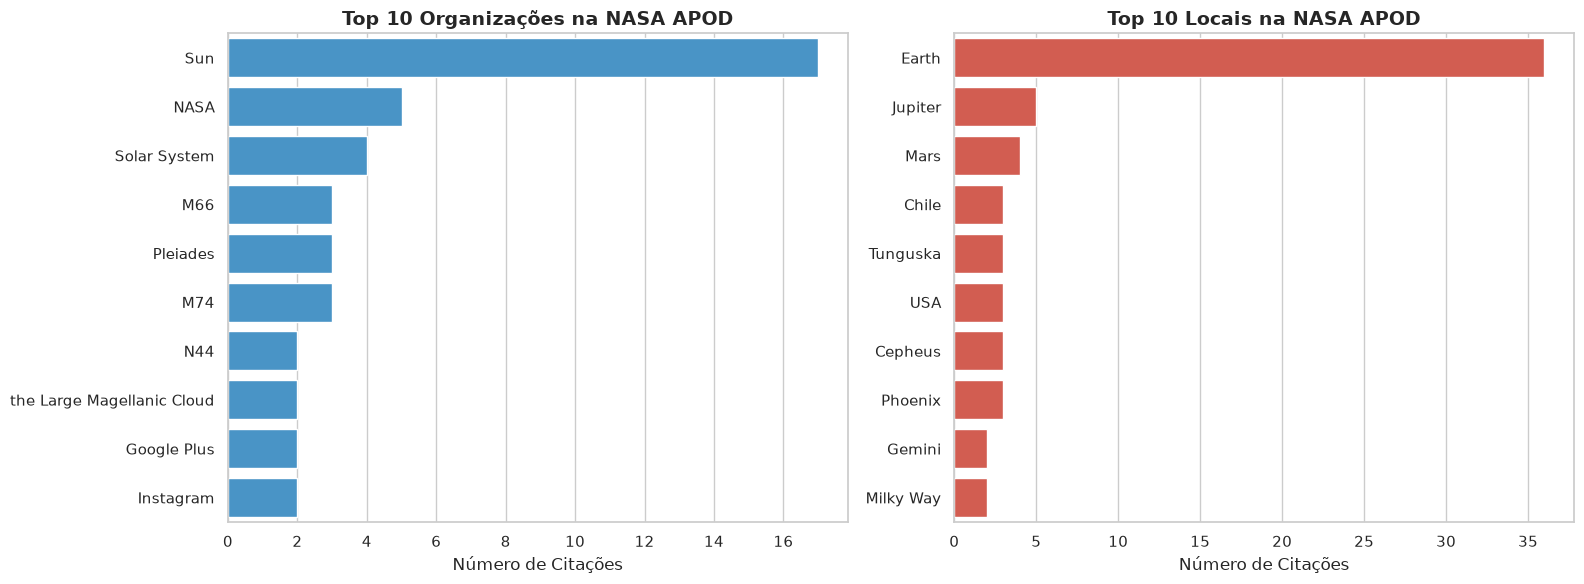

In [6]:
import spacy
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Garantindo que o modelo e o estilo visual estão configurados
nlp = spacy.load("en_core_web_sm")
sns.set_theme(style="whitegrid", palette="pastel")

print("Garimpando Entidades nas 50 publicações da NASA...")

# Listas vazias para armazenar todas as entidades que encontrar
todas_orgs = []
todos_locais = []

# Iterando sobre os textos ORIGINAIS (O NER precisa das letras maiúsculas!)
for texto in df_apod['explanation']:
    if not isinstance(texto, str):
        continue # Pula se houver alguma linha vazia
        
    doc = nlp(texto) # A IA processa o texto
    
    for entidade in doc.ents:
        # Extraindo Organizações (Empresas, Agências, Universidades)
        if entidade.label_ == "ORG":
            # Limpa espaços extras e quebras de linha que possam vir no texto
            todas_orgs.append(entidade.text.strip().replace('\n', ' '))
            
        # Extraindo Locais (GPE = Países/Cidades, LOC = Rios/Planetas/Galáxias)
        elif entidade.label_ in ["GPE", "LOC"]:
            todos_locais.append(entidade.text.strip().replace('\n', ' '))

# Contando e pegando o Top 10
top_10_orgs = Counter(todas_orgs).most_common(10)
top_10_locais = Counter(todos_locais).most_common(10)

# EXIBIÇÃO EM TEXTO

print("\n--- 🏆 TOP 10 ORGANIZAÇÕES MAIS CITADAS ---")
for org, contagem in top_10_orgs:
    print(f"{org:<35} | {contagem} citações")

print("\n--- 🌍 TOP 10 LOCAIS MAIS CITADOS ---")
for local, contagem in top_10_locais:
    print(f"{local:<35} | {contagem} citações")

# VISUALIZAÇÃO GRÁFICA 

# Convertendo para DataFrames apenas para facilitar o uso do Seaborn
df_orgs = pd.DataFrame(top_10_orgs, columns=['Organização', 'Citações'])
df_locais = pd.DataFrame(top_10_locais, columns=['Local', 'Citações'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Organizações
sns.barplot(data=df_orgs, x='Citações', y='Organização', ax=axes[0], color='#3498db')
axes[0].set_title('Top 10 Organizações na NASA APOD', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Número de Citações')
axes[0].set_ylabel('')

# Gráfico 2: Locais
sns.barplot(data=df_locais, x='Citações', y='Local', ax=axes[1], color='#e74c3c')
axes[1].set_title('Top 10 Locais na NASA APOD', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Número de Citações')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()